## output of autocorrelation function

`/project/spott/cshan/fiber-seq/code/clustering_methods/auto_correlation/03_compute_autocorrelations.py`

In [2]:
import sys
import numpy as np
from pathlib import Path

code_dir = Path(
    "/project/spott/cshan/fiber-seq/code/clustering_methods/auto_correlation"
)
sys.path.insert(0, str(code_dir))

import importlib

acf = importlib.import_module("03_compute_autocorrelations")

Select rank 1 from the saved analysis inputs. The `rank01_` prefix is the original AS-FIRE selection rank. Run all cells using the Jupyter-notebook Python environment.


In [3]:
run_dir = code_dir.parents[2] / "LCL_project/auto_correlation/resolution04"
region_dirs = sorted(p for p in (run_dir / "inputs").glob("rank01_*") if p.is_dir())
if len(region_dirs) != 1:
    raise RuntimeError(f"Expected exactly one rank-1 region in {run_dir / 'inputs'}, found {len(region_dirs)}")
region_id = region_dirs[0].name
input_file = region_dirs[0] / "m6a_input.npz"
if not input_file.is_file():
    raise FileNotFoundError(f"Saved m6A input is missing: {input_file}")
print("Selected region:", region_id)
print("Input:", input_file)


Selected region: rank01_rs12470189_chr2_119290945_119291178
Input: /project/spott/cshan/fiber-seq/LCL_project/auto_correlation/resolution04/inputs/rank01_rs12470189_chr2_119290945_119291178/m6a_input.npz


load m6a binary matrix

In [4]:
import json

with np.load(input_file, allow_pickle=False) as x:
    binary = x["matrix"]
    region = json.loads(x["provenance"].item())["region"]
if region["region_id"] != region_id or int(region["rank"]) != 1:
    raise ValueError("Saved input provenance does not match the selected rank-1 region")
print(f"Analysis window: {region['chr']}:{region['analysis_start']}-{region['analysis_end']} (1-based)")
print("Matrix shape (reads, bases):", binary.shape)
print("Matrix dtype:", binary.dtype)


Analysis window: chr2:119290056-119292055 (1-based)
Matrix shape (reads, bases): (255, 2000)
Matrix dtype: uint8


calculate ACF

In [5]:
profiles, valid = acf.autocorrelations(binary)

print("binary:", binary.shape)
print("profiles:", profiles.shape)
print("valid:", valid.shape)
print("valid reads:", valid.sum())

binary: (255, 2000)
profiles: (255, 2000)
valid: (255,)
valid reads: 255


inspect one read

In [6]:
valid_indices = np.flatnonzero(valid)
if not len(valid_indices):
    raise ValueError(f"No reads with nonzero variance in {region_id}")
i = int(valid_indices[0])
print("Read index:", i)
print("Binary m6A:")
print(binary[i, :50])
print("\nFirst 50 ACF values:")
print(profiles[i, :50])
print("\nValid:", valid[i])


Read index: 0
Binary m6A:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0]

First 50 ACF values:
[ 1.         -0.03143657  0.15494174  0.13006646  0.10519117  0.1424493
  0.1300007   0.12997878  0.1672369  -0.00675857  0.05535292  0.08018436
  0.10501581  0.10499389  0.10497197  0.08009668  0.06764808  0.09247952
  0.06760424  0.11781097  0.06808231  0.05563371  0.05561179  0.08044323
  0.09336992  0.0187879   0.08089939  0.05602411  0.01872214  0.08083363
  0.03110498  0.05593643  0.03106114 -0.00624083  0.10557739  0.00614201
  0.04340014  0.04337822  0.03092962  0.04333438  0.01845909  0.01843717
  0.06812198  0.03082001  0.03079809  0.01834949  0.01832757  0.03073233
  0.00585704  0.05606377]

Valid: True


## find the strongest peak that falls in nucleosome repeat length (140-250bp)

In [7]:
summaries = importlib.import_module("05_summarize_autocorrelations")

lag, height = summaries.repeat_peak(profiles[i])

print("Peak lag:", lag)
print("Peak ACF:", height)

Peak lag: 194
Peak ACF: 0.10676737250223525


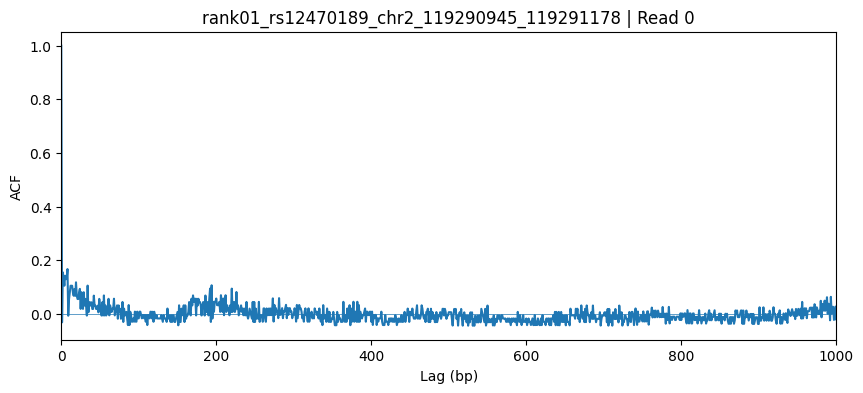

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(np.arange(profiles.shape[1]), profiles[i])
plt.axhline(0, linewidth=0.5)
plt.xlim(0, 1000)
plt.xlabel("Lag (bp)")
plt.ylabel("ACF")
plt.title(f"{region_id} | Read {i}")
plt.show()

Zoom in to nucleosome-scale spacing for the same read.


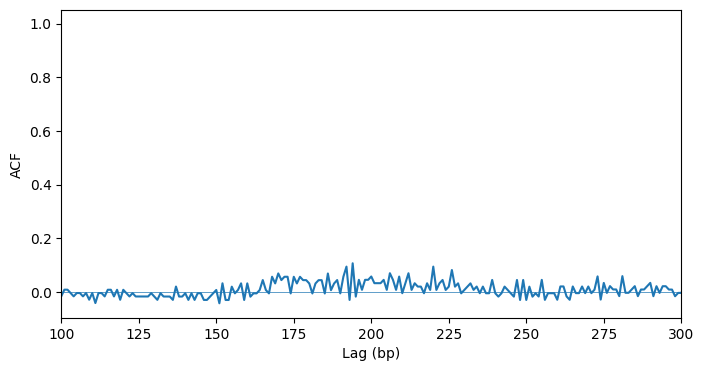

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(np.arange(profiles.shape[1]), profiles[i])
plt.axhline(0, linewidth=0.5)
plt.xlim(100, 300)
plt.xlabel("Lag (bp)")
plt.ylabel("ACF")
plt.show()

inspect reads as ACF heatmap

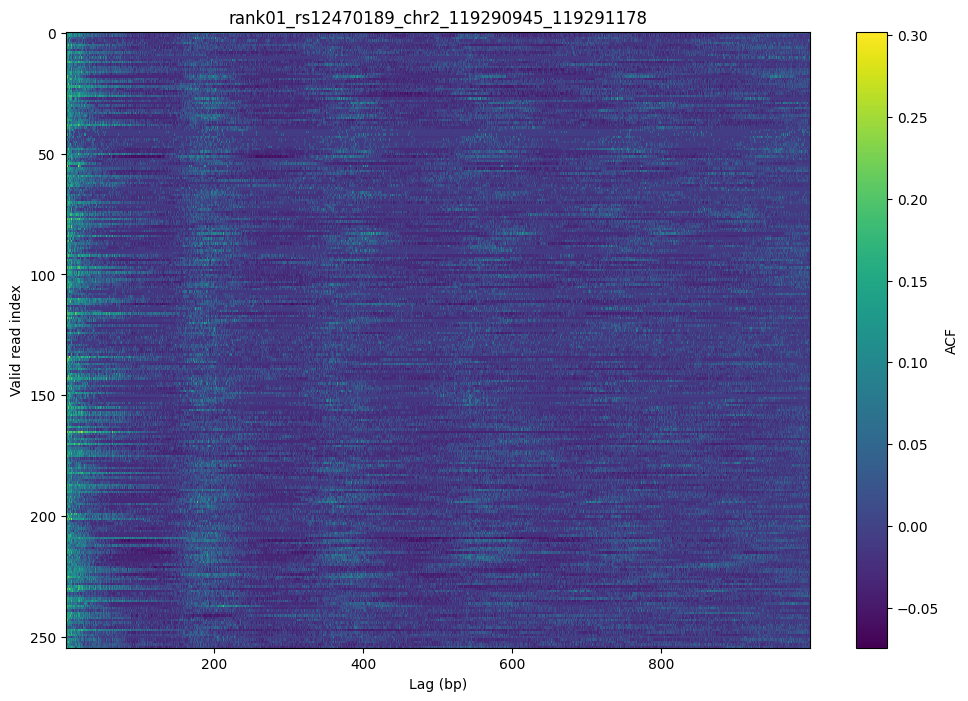

In [10]:
valid_profiles = profiles[valid]
last_lag = min(999, profiles.shape[1] - 1)

plt.figure(figsize=(12, 8))
plt.imshow(
    valid_profiles[:, 1:last_lag + 1],
    aspect="auto",
    interpolation="nearest",
    extent=(0.5, last_lag + 0.5, len(valid_profiles) - 0.5, -0.5)
)
plt.xlabel("Lag (bp)")
plt.ylabel("Valid read index")
plt.title(region_id)
plt.colorbar(label="ACF")
plt.show()